# CA4: CA Groups 11
## Indra Bdr Adhikari, Zarar Zafar, and Syed Muhammad Murtaza Zaidi

## BACKGROUND

You have been hired by Nordic Bank Group, a financial services provider operating across Scandinavia. The bank is experiencing customer churn, where customers close their accounts and move to competing banks. Retaining existing customers is often significantly cheaper than acquiring new ones.

Your task is to develop a machine learning model capable of predicting whether a customer will leave the bank based on demographic and financial information. Accurate churn prediction models allow companies to identify customers who may leave and take proactive measures to retain them.

## 1. Imports

In [649]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # to ignore warning 

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Dimension reduction
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Model selection & evaluation
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Global random state
RANDOM_STATE = 42

# refference: used chat to organized imported libraries

## 2. Reading data

In [650]:
# Load the test data
test = pd.read_csv("test.csv")
print(test.shape)
test.head(1)

(2000, 13)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,5703,15749540,Hsiung,585,France,Male,36,7,0.0,2,1,0,94283.09


In [651]:
# Load the train data
df = pd.read_csv("train.csv")
print(df.info())
df.head(2)

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        8000 non-null   int64  
 1   CustomerId       8000 non-null   int64  
 2   Surname          8000 non-null   str    
 3   CreditScore      8000 non-null   int64  
 4   Geography        8000 non-null   str    
 5   Gender           8000 non-null   str    
 6   Age              8000 non-null   int64  
 7   Tenure           8000 non-null   int64  
 8   Balance          8000 non-null   float64
 9   NumOfProducts    8000 non-null   int64  
 10  HasCrCard        8000 non-null   int64  
 11  IsActiveMember   8000 non-null   int64  
 12  EstimatedSalary  8000 non-null   float64
 13  Exited           8000 non-null   int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1010.6 KB
None


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2152,15588614,Walton,753,France,Male,57,7,0.00,1,1,0,159475.08,1
1,8393,15641158,Belcher,739,Germany,Male,32,3,102128.27,1,1,0,63981.37,1


## 3. Data exploration and visualisation

In [652]:
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [653]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,8000.000000,8.000000e+03,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000
mean,4990.432875,1.569088e+07,650.752500,38.946625,5.016625,76381.207499,1.529500,0.708750,0.514875,99730.811581,0.20375
std,2896.482331,7.193619e+04,96.596432,10.526876,2.896791,62302.053597,0.581741,0.454367,0.499810,57335.116540,0.40281
min,1.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.00000
25%,2461.750000,1.562869e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50691.817500,0.00000
50%,4987.500000,1.568995e+07,652.000000,37.000000,5.000000,97055.145000,1.000000,1.000000,1.000000,99446.940000,0.00000
75%,7509.500000,1.575327e+07,717.000000,44.000000,8.000000,127633.195000,2.000000,1.000000,1.000000,148527.730000,0.00000
max,10000.000000,1.581569e+07,850.000000,92.000000,10.000000,238387.560000,4.000000,1.000000,1.000000,199992.480000,1.00000


In [654]:
# Creating new df without irevalent columns
new_df = df.drop(columns = ['Surname', 'CustomerId', 'RowNumber'])
test_df = test.drop(columns = ['Surname', 'CustomerId', 'RowNumber'])
new_df.shape

(8000, 11)

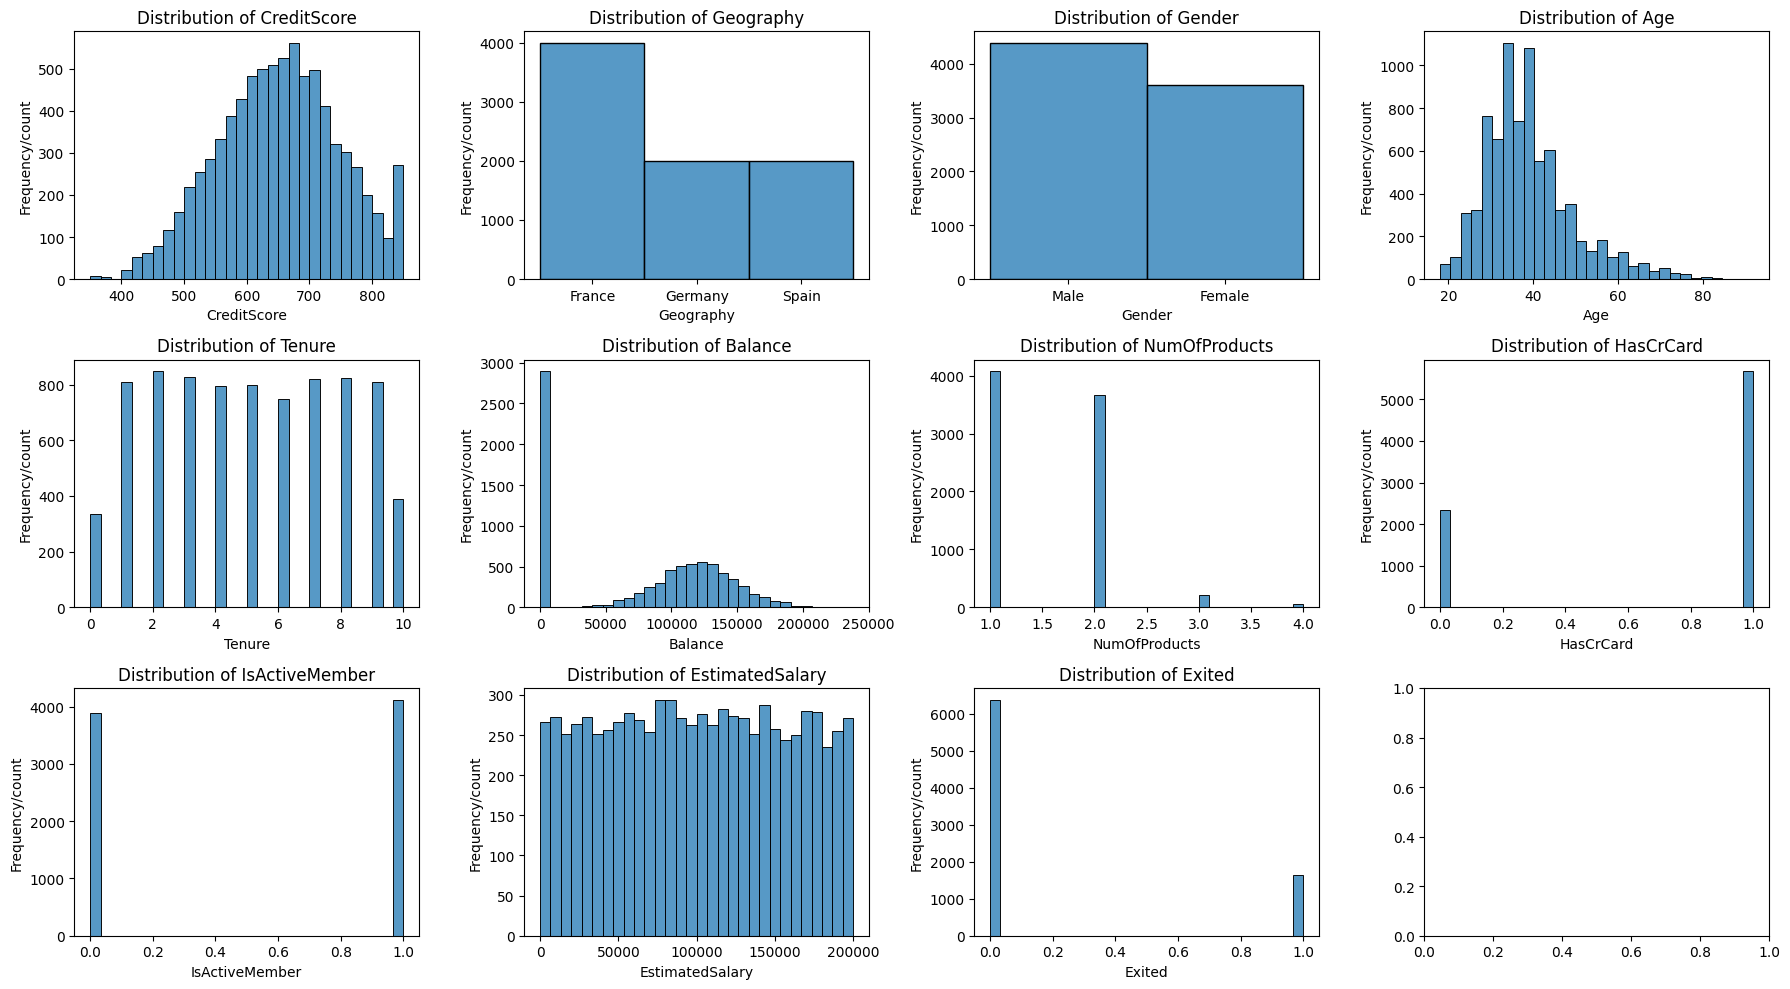

In [655]:
# features = new_df.columns.drop("Exited")

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(new_df.columns):
    sns.histplot(df[feature], bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency/count')

plt.tight_layout()
plt.show()

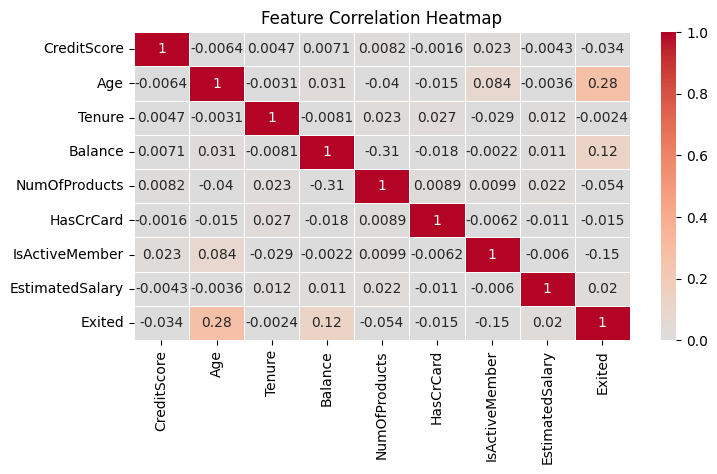

In [656]:
# Calculate the correlation matrix for numeric columns only and except "ID" columns
corr_matrix = new_df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(8, 4))

# Draw the heatmap
sns.heatmap(corr_matrix, 
            annot=True,      
            cmap='coolwarm',
            vmin=0, vmax=1, 
            center=0,        # Ensure 0 is the neutral color 
            linewidths=0.5)  # Add small gaps

plt.title("Feature Correlation Heatmap")
plt.show()

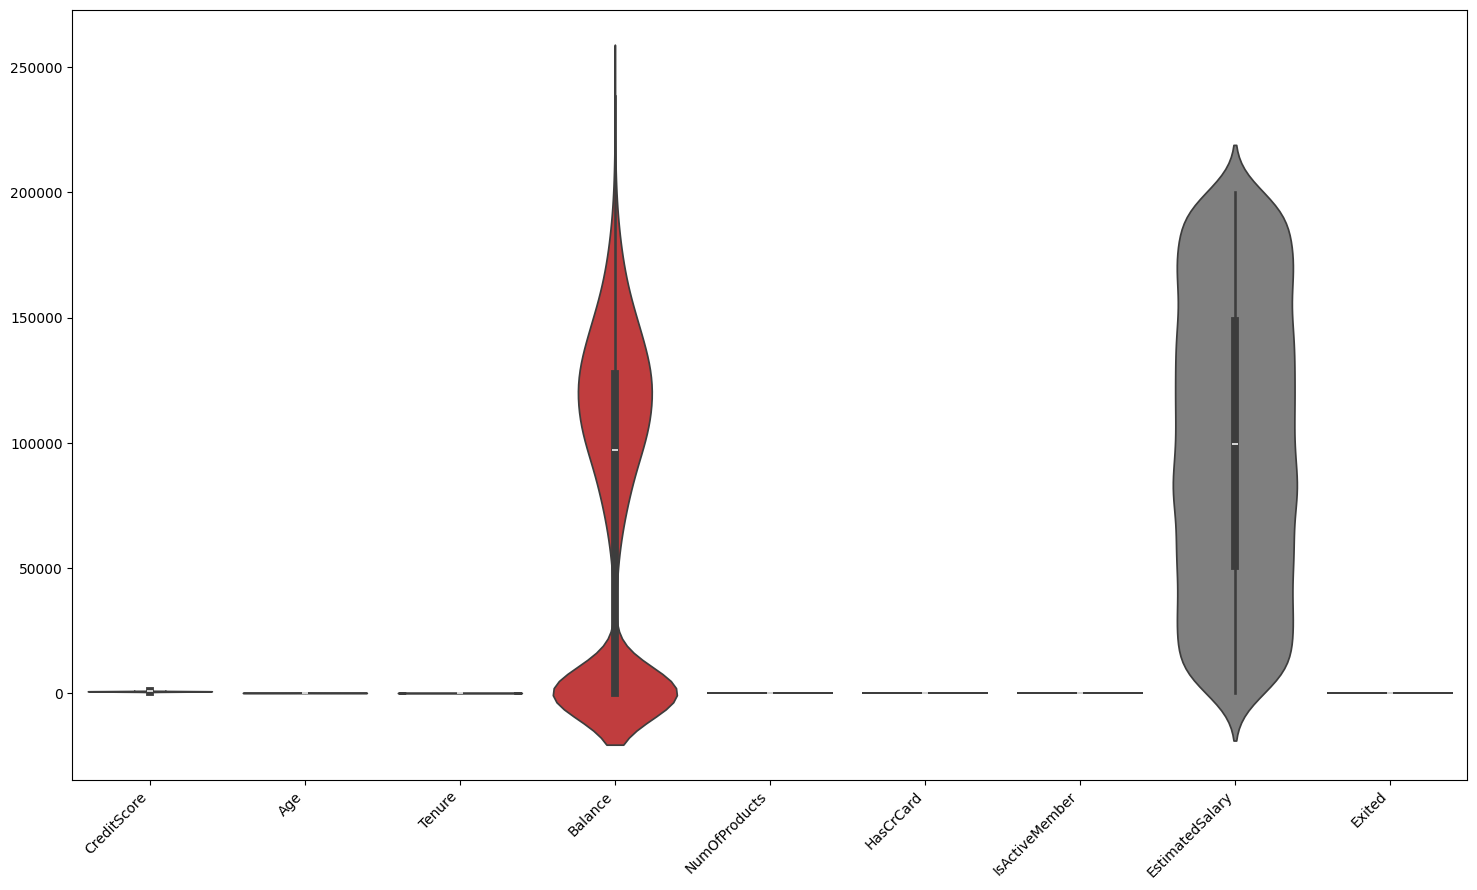

In [657]:
# Identify value ranges and potential outliers
cols=new_df.columns

fig, ax = plt.subplots(1, 1, figsize=(18, 10))  

data = pd.DataFrame(df, columns=cols)  

sns.violinplot(data=data, ax=ax)
plt.xticks(rotation=45, ha='right')
plt.show()

## 4.  Data cleaning


In [658]:
# Duplicates
print(new_df.duplicated().sum())
test_df.duplicated().sum()

0


0

In [659]:
new_df.columns.tolist()

['CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [660]:
# Standardise column names
new_df.columns = new_df.columns.str.lower()
test_df.columns = test_df.columns.str.lower()
# features = features.str.lower()
# checking features data type
new_df[new_df.columns].dtypes

creditscore          int64
geography              str
gender                 str
age                  int64
tenure               int64
balance            float64
numofproducts        int64
hascrcard            int64
isactivemember       int64
estimatedsalary    float64
exited               int64
dtype: object

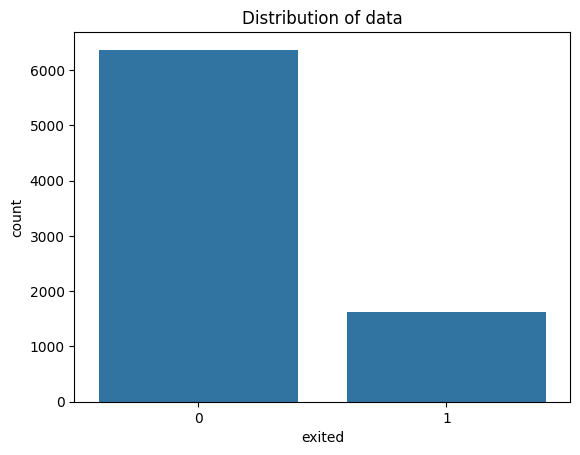

In [661]:
#verify class balance
sns.countplot(x='exited', data=new_df)
plt.title('Distribution of data')
plt.show()

## 5. Data preprocessing

In [662]:
new_df["gender"].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [663]:
new_df["geography"].unique()

<ArrowStringArray>
['France', 'Germany', 'Spain']
Length: 3, dtype: str

In [664]:
# Checking corrilation of new df
new_df.select_dtypes(include=['number']).corr()

,creditscore,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
creditscore,1.000000,-0.006425,0.004685,0.007147,0.008190,-0.001597,0.023358,-0.004345,-0.033998
age,-0.006425,1.000000,-0.003119,0.030534,-0.039602,-0.015352,0.083611,-0.003579,0.280378
tenure,0.004685,-0.003119,1.000000,-0.008097,0.022892,0.027235,-0.028881,0.011986,-0.002368
balance,0.007147,0.030534,-0.008097,1.000000,-0.307659,-0.017914,-0.002175,0.010551,0.121441
numofproducts,0.008190,-0.039602,0.022892,-0.307659,1.000000,0.008861,0.009885,0.022144,-0.054462
hascrcard,-0.001597,-0.015352,0.027235,-0.017914,0.008861,1.000000,-0.006243,-0.010796,-0.014524
isactivemember,0.023358,0.083611,-0.028881,-0.002175,0.009885,-0.006243,1.000000,-0.006004,-0.152286
estimatedsalary,-0.004345,-0.003579,0.011986,0.010551,0.022144,-0.010796,-0.006004,1.000000,0.020260
exited,-0.033998,0.280378,-0.002368,0.121441,-0.054462,-0.014524,-0.152286,0.020260,1.000000


In [665]:
# Checking for missing values in the feature matrix and target
target = 'exited'
features = new_df.select_dtypes(include=['number']).columns.drop(target)

X = new_df[features]
y = new_df[target]

print(X.isnull().sum())
y.isnull().sum()

creditscore        0
age                0
tenure             0
balance            0
numofproducts      0
hascrcard          0
isactivemember     0
estimatedsalary    0
dtype: int64


0

Feature ranking (descending importance):
 1) 0.2544 age
 2) 0.1666 estimatedsalary
 3) 0.1635 creditscore
 4) 0.1484 balance
 5) 0.1227 numofproducts
 6) 0.0865 tenure
 7) 0.0407 isactivemember
 8) 0.0171 hascrcard


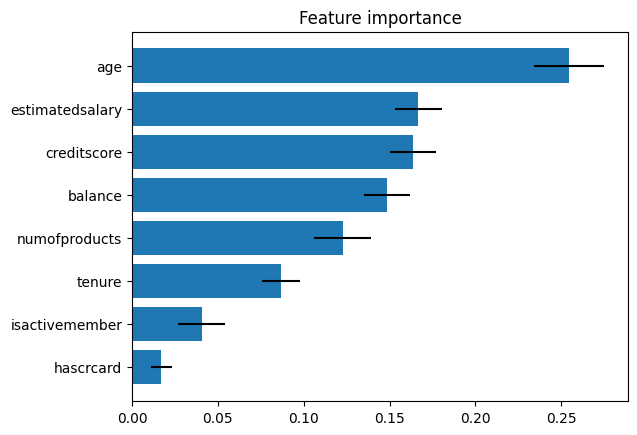

In [666]:
# Source; from lecture 12, to use the random forrest for features selection.

# Split the data into a training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a random forest classifier
clf = RandomForestClassifier(n_estimators=500, random_state=42)
clf.fit(X_train, y_train)

# Print the feature ranking as a list
print("Feature ranking (descending importance):")
ranking = { features[i]: clf.feature_importances_[i] for i in range(X.shape[1]) }
feature_name_max_length = max(ranking.keys(), key=len)
for i, feature in enumerate(sorted(ranking, key=ranking.get, reverse=True)):
    print(f"{i+1:2d}) {ranking[feature]:.4f} {feature}")

# Plot the feature importances of the forest
# Feature names on the y-axis, importances on the x-axis
# The most important features are at the top
# This means we first have to sort the features
feature_importance = clf.feature_importances_
indices = np.argsort(feature_importance)

plt.figure()
plt.title("Feature importance")
plt.yticks(range(X.shape[1]), np.array(features)[indices])

# Add error bars as well by computing the standard deviation of the feature importances
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)
plt.barh(range(X.shape[1]), feature_importance[indices], xerr=std[indices], align="center")

plt.show()

In [667]:
# features engineering
new_df['balance_per_product'] = new_df['balance'] / (new_df['numofproducts'] + 1)
new_df['age_credit_ratio'] = new_df['age'] / (new_df['creditscore'] + 1)
new_df['active_balance'] = new_df['balance'] * new_df['isactivemember']
new_df['age_group'] = pd.cut(new_df['age'], bins=[0, 30, 45, 60, 100],
                            labels=['Young', 'MiddleAge', 'Senior', 'Elder'])
new_df['age_group'] = new_df['age_group'].astype(str)
new_df['zero_balance'] = (new_df['balance'] == 0).astype(int)


test_df['balance_per_product'] = test_df['balance'] / (test_df['numofproducts'] + 1)
test_df['age_credit_ratio'] = test_df['age'] / (test_df['creditscore'] + 1)
test_df['active_balance'] = test_df['balance'] * test_df['isactivemember']
test_df['age_group'] = pd.cut(test_df['age'], bins=[0, 30, 45, 60, 100],
                            labels=['Young', 'MiddleAge', 'Senior', 'Elder'])
test_df['age_group'] = test_df['age_group'].astype(str)
test_df['zero_balance'] = (test_df['balance'] == 0).astype(int)


new_df.head(2)

,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,balance_per_product,age_credit_ratio,active_balance,age_group,zero_balance
0,753,France,Male,57,7,0.00,1,1,0,159475.08,1,0.000,0.075597,0.0,Senior,1
1,739,Germany,Male,32,3,102128.27,1,1,0,63981.37,1,51064.135,0.043243,0.0,MiddleAge,0


Feature ranking (descending importance):
 1) 0.1815 age
 2) 0.1503 age_credit_ratio
 3) 0.1126 creditscore
 4) 0.1126 estimatedsalary
 5) 0.1108 numofproducts
 6) 0.0865 balance_per_product
 7) 0.0832 balance
 8) 0.0637 tenure
 9) 0.0440 active_balance
10) 0.0323 isactivemember
11) 0.0158 hascrcard
12) 0.0065 zero_balance


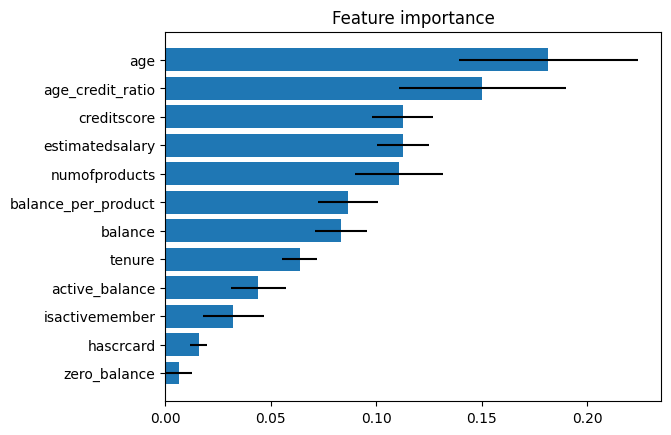

In [668]:
# Source; from lecture 12, to use the random forrest for features selection.
# Checking for missing values in the feature matrix and target
new_features = new_df.select_dtypes(include=['number']).columns.drop(target)

X = new_df[new_features]
y = new_df[target]

# Split the data into a training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a random forest classifier
clf = RandomForestClassifier(n_estimators=500, random_state=42)
clf.fit(X_train, y_train)

# Print the feature ranking as a list
print("Feature ranking (descending importance):")
ranking = { new_features[i]: clf.feature_importances_[i] for i in range(X.shape[1]) }
feature_name_max_length = max(ranking.keys(), key=len)
for i, feature in enumerate(sorted(ranking, key=ranking.get, reverse=True)):
    print(f"{i+1:2d}) {ranking[feature]:.4f} {feature}")

# Plot the feature importances of the forest
# Feature names on the y-axis, importances on the x-axis
# The most important features are at the top
# This means we first have to sort the features
feature_importance = clf.feature_importances_
indices = np.argsort(feature_importance)

plt.figure()
plt.title("Feature importance")
plt.yticks(range(X.shape[1]), np.array(new_features)[indices])

# Add error bars as well by computing the standard deviation of the feature importances
std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)
plt.barh(range(X.shape[1]), feature_importance[indices], xerr=std[indices], align="center")

plt.show()

In [669]:
# excluding these columns as they have minimum effect for prediction
new_df = new_df.drop(columns=['active_balance', 'hascrcard', 'tenure','isactivemember', 'hascrcard','zero_balance'])
test_df = test_df.drop(columns=['active_balance', 'hascrcard', 'tenure','isactivemember', 'hascrcard','zero_balance'])

## 6. Preprocessing Setup

In [670]:
TARGET = 'exited'
X = new_df.drop(columns=[TARGET])
y = new_df[TARGET]

# identify column types
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols     = X.select_dtypes(include=np.number).columns.tolist()

print('Categorical:', categorical_cols)
print('Numeric    :', numeric_cols)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # fill missing with median
    ('scaler',  StandardScaler())                   # scale the numbers
])
 
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # fill missing with mode
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# 60 to 40 split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')
print(f'Class balance (train): {y_train.value_counts().to_dict()}')

Categorical: ['geography', 'gender', 'age_group']
Numeric    : ['creditscore', 'age', 'balance', 'numofproducts', 'estimatedsalary', 'balance_per_product', 'age_credit_ratio']

Train: (4800, 10), Test: (3200, 10)
Class balance (train): {0: 3822, 1: 978}


## 7. Cross-Validation Helper

In [671]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = 'f1_macro'

def cv_report(pipeline, X, y, label): # function for future use for every pipelines
    # Run 5-fold CV and print macro F1.
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=SCORING, n_jobs=-1)
    print(f'{label:<45} macro-F1: {scores.mean():.4f} ± {scores.std():.4f}')
    return scores.mean()

## 8. Pipelines

### 8.1 Pipelines 1 – SVM with RBF Kernel + PCA

In [672]:
# Build SVC base pipeline
pipe_svm = Pipeline([
    ('prep', preprocessor),
    ('pca',  PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ('clf',  SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE))
])

# Quick baseline CV
cv_report(pipe_svm, X, y, 'SVM RBF + PCA (baseline)')

SVM RBF + PCA (baseline)                      macro-F1: 0.7036 ± 0.0075


0.7035591460151505

In [673]:
# Hyperparameter tuning with GridSearchCV for SVM
param_grid_svm = {
    'pca__n_components': [0.90, 0.95],
    'clf__C':     [0.1, 1, 10, 50],
    'clf__gamma': ['scale', 'auto'],
}

gs_svm = GridSearchCV(
    pipe_svm, param_grid_svm,
    cv=cv, scoring=SCORING, n_jobs=-1, verbose=1
)
gs_svm.fit(X_train, y_train)

print('Best params (SVM):', gs_svm.best_params_)
print(f'Best CV macro-F1 : {gs_svm.best_score_:.4f}')
best_svm = gs_svm.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits


Best params (SVM): {'clf__C': 1, 'clf__gamma': 'auto', 'pca__n_components': 0.95}
Best CV macro-F1 : 0.6993


### 8.2 Pipeline 2 – Logistic Regression with L1/L2 Regularisation

In [674]:
pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(
        penalty='l2', solver='lbfgs', max_iter=1000,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

cv_report(pipe_lr, X, y, 'LogReg L2 (baseline)')

LogReg L2 (baseline)                          macro-F1: 0.6542 ± 0.0120


0.6542191966896505

In [675]:
# testing L1 via liblinear solver
pipe_lr_l1 = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(
        penalty='l1', solver='liblinear', max_iter=1000,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])
cv_report(pipe_lr_l1, X, y, 'LogReg L1 (baseline)')

LogReg L1 (baseline)                          macro-F1: 0.6542 ± 0.0121


0.6542000343587887

In [676]:
# Tuning C for L2 with gridsearch
param_grid_lr = {
    'clf__C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
}
gs_lr = GridSearchCV(
    pipe_lr, param_grid_lr,
    cv=cv, scoring=SCORING, n_jobs=-1, verbose=0
)
gs_lr.fit(X_train, y_train)

print('Best params (LR L2):', gs_lr.best_params_)
print(f'Best CV macro-F1   : {gs_lr.best_score_:.4f}')
best_lr = gs_lr.best_estimator_

Best params (LR L2): {'clf__C': 0.01}
Best CV macro-F1   : 0.6548


### 8.3 Pipeline 3 – Random Forest with Randomized Search CV and PCA

In [677]:
pipe_rf = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

cv_report(pipe_rf, X, y, 'RandomForest')

RandomForest                                  macro-F1: 0.7145 ± 0.0157


0.7144596136823088

In [678]:
# Hyperparameter search space for RF
param_dist_rf = {
    'clf__n_estimators':      [100, 200, 300, 500],
    'clf__max_depth':         [None, 10, 15, 20, 30],
    'clf__max_features':      ['sqrt', 'log2', 0.3, 0.5],
    'clf__min_samples_leaf':  [1, 3, 5, 10],
    'clf__min_samples_split': [2, 5, 10],
    'clf__class_weight':      ['balanced', 'balanced_subsample'],
}
# using RandomizedSearchCV intead of gridsearch to increase run time
rs_rf = RandomizedSearchCV(
    pipe_rf, 
    param_dist_rf,
    n_iter=30,              # Increased since this have more params to explore
    cv=cv, 
    scoring=SCORING,
    n_jobs=-1, 
    verbose=1, 
    random_state=RANDOM_STATE
)
rs_rf.fit(X_train, y_train)

print('Best params (RF):', rs_rf.best_params_)
print(f'Best CV macro-F1 : {rs_rf.best_score_:.4f}')
best_rf = rs_rf.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (RF): {'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 3, 'clf__max_features': 0.5, 'clf__max_depth': 20, 'clf__class_weight': 'balanced_subsample'}
Best CV macro-F1 : 0.7375


### 8.4 Pipeline 4 - KNeighborsClassifier + PCA

In [679]:
# KNeighborsClassifier
pipe_knn = Pipeline([
    ('prep', preprocessor),
    ('pca',  PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ('clf',  KNeighborsClassifier())
])
cv_report(pipe_knn, X, y, 'KNN + PCA (baseline)')

KNN + PCA (baseline)                          macro-F1: 0.6955 ± 0.0146


0.6955443438076536

In [680]:
# tunning
param_grid_knn = {
    'pca__n_components': [0.90, 0.95],
    'clf__n_neighbors':  [3, 5, 7, 11, 15, 21],
    'clf__weights':      ['uniform', 'distance'],
    'clf__metric':       ['euclidean', 'manhattan'],
}
gs_knn = GridSearchCV(
    pipe_knn, param_grid_knn,
    cv=cv, scoring=SCORING, n_jobs=-1, verbose=1
)
gs_knn.fit(X_train, y_train)
print('Best params (KNN):', gs_knn.best_params_)
print(f'Best CV macro-F1 : {gs_knn.best_score_:.4f}')
best_knn = gs_knn.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params (KNN): {'clf__metric': 'manhattan', 'clf__n_neighbors': 5, 'clf__weights': 'distance', 'pca__n_components': 0.95}
Best CV macro-F1 : 0.6956


## 9. Model Comparison


Model Comparison (5-fold CV, macro-F1):
                            mean       std
Random Forest           0.741512  0.015703
SVM RBF + PCA           0.703674  0.007213
KNN + PCA               0.697538  0.014749
Logistic Regression L2  0.653827  0.018116


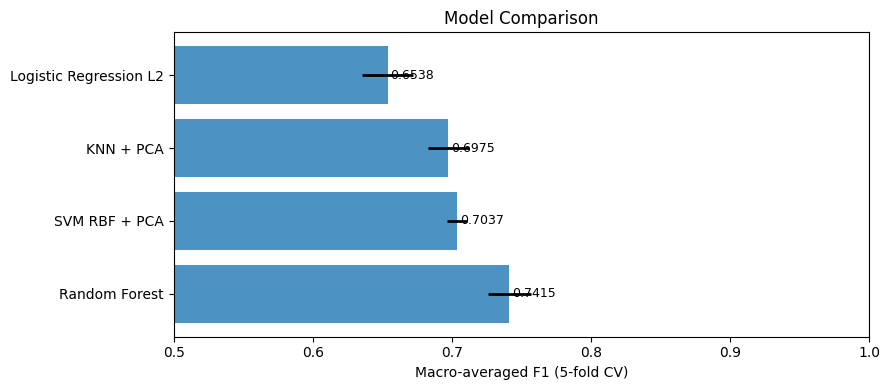


 Best model: Random Forest


In [681]:
models = {
    'SVM RBF + PCA':          best_svm,
    'Logistic Regression L2': best_lr,
    'Random Forest':          best_rf,
    'KNN + PCA':              best_knn,
}

comparison = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring=SCORING, n_jobs=-1)
    comparison[name] = {'mean': scores.mean(), 'std': scores.std()}

comp_df = pd.DataFrame(comparison).T.sort_values('mean', ascending=False)
print('\nModel Comparison (5-fold CV, macro-F1):')
print(comp_df.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(comp_df.index, comp_df['mean'],
        xerr=comp_df['std'], alpha=0.8,
        error_kw={'elinewidth': 2})
ax.set_xlabel('Macro-averaged F1 (5-fold CV)')
ax.set_title('Model Comparison')
ax.set_xlim(0.5, 1.0)
for i, (m, s) in enumerate(zip(comp_df['mean'], comp_df['std'])):
    ax.text(m + 0.002, i, f'{m:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

best_model_name = comp_df['mean'].idxmax()
best_model = models[best_model_name]
print(f'\n Best model: {best_model_name}')

## 10. Confusion Matrix – Final Evaluation

Final Evaluation — Random Forest
Macro-averaged F1 : 0.7499
Accuracy          : 0.8394


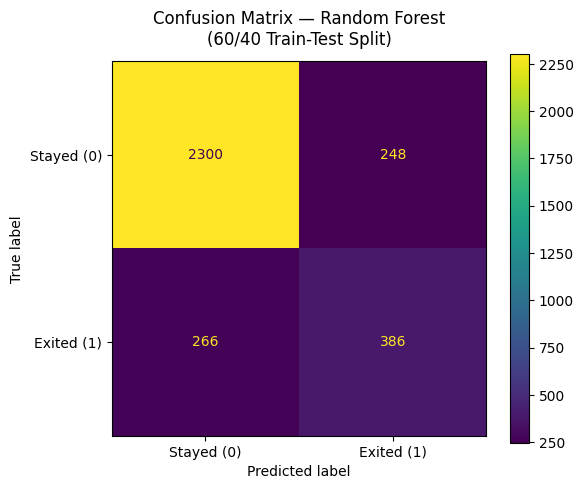

Confusion matrix saved to confusion_matrix.png


In [682]:
# Re-fit best model
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print(f'Final Evaluation — {best_model_name}')
print(f'Macro-averaged F1 : {f1_score(y_test, y_pred, average="macro"):.4f}')
print(f'Accuracy          : {accuracy_score(y_test, y_pred):.4f}')

#  Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Stayed (0)', 'Exited (1)'])
disp.plot(ax=ax, colorbar=True)
ax.set_title(f'Confusion Matrix — {best_model_name}\n(60/40 Train-Test Split)', pad=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved to confusion_matrix.png')

## 11. Kaggle Submission

In [683]:
# For customer ID for the test submission file
test_ids = pd.read_csv('test.csv')['CustomerId']

# Retrain best model on ALL training data
best_model.fit(X, y)

X_sub = test_df.copy()
kaggle_preds = best_model.predict(X_sub)

test_ids = pd.read_csv('test.csv')['CustomerId']

submission = pd.DataFrame({'CustomerId': test_ids, 'Exited': kaggle_preds})
submission.to_csv('submission.csv', index=False)

print('File saved: submission.csv')
print(submission['Exited'].value_counts())
submission.head(1)

File saved: submission.csv
Exited
0    1589
1     411
Name: count, dtype: int64


,CustomerId,Exited
0,15749540,0
